In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18, vit_b_16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#load data
def get_cifar_loaders(dataset="cifar10", batch_size=128):
    normalize = T.Normalize((0.4914, 0.4822, 0.4465),
                            (0.2470, 0.2435, 0.2616))

    train_tf = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        normalize,
    ])
    test_tf = T.Compose([
        T.ToTensor(),
        normalize,
    ])

    if dataset.lower() == "cifar10":
        trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tf)
        testset = torchvision.datasets.CIFAR10(root="./data", train=False,download=True, transform=test_tf)
        num_classes = 10
    else:
        trainset = torchvision.datasets.CIFAR100(root="./data", train=True, download=True, transform=train_tf)
        testset = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=test_tf)
        num_classes = 100
        
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,shuffle=False, num_workers=2)
    return trainloader, testloader, num_classes

#Models
def get_resnet(num_classes):
    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_vit(num_classes):
    # ViT-B/16 adapted to 32x32 by changing image_size
    model = vit_b_16(weights=None, image_size=32)
    model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    return model

#Train anf evaluation loops
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        _, pred = out.max(1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

@torch.no_grad()
def eval_model(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        running_loss += loss.item() * x.size(0)
        _, pred = out.max(1)
        correct += pred.eq(y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

#run the models
def run_baseline(model_name="resnet", dataset="cifar10", epochs=25, lr=0.1):
    trainloader, testloader, num_classes = get_cifar_loaders(dataset)
    if model_name == "resnet":
        model = get_resnet(num_classes)
    else:
        model = get_vit(num_classes)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 40], gamma=0.1)
    history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, trainloader, criterion, optimizer)
        test_loss, test_acc = eval_model(model, testloader, criterion)
        scheduler.step()
        history["loss"].append(train_loss)
        history["acc"].append(train_acc)
        history["val_loss"].append(test_loss)
        history["val_acc"].append(test_acc)
        print(f"[{dataset.upper()}][{model_name.upper()}] "
              f"Epoch {epoch:03d} | "
              f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
              f"Test Loss {test_loss:.4f} Acc {test_acc:.4f}")
    return model, history

In [7]:
import matplotlib.pyplot as plt
def plot_learning(history):
    tgts = ['loss', 'acc']
    vtgts = ['val_loss', 'val_acc']
    plt.figure(figsize=(10,3))
    for i, (tgt, val_tgt) in enumerate(zip(tgts, vtgts)):
        plt.subplot(1,2, i+1)
        plt.plot(history[tgt], label=tgt)
        plt.plot(history[val_tgt], label=val_tgt)
        plt.xlabel('Epoch')
        plt.legend()
        plt.title(f"Training and validation {tgt}")

In [ ]:
# ResNet vs ViT on CIFAR-10 (we did not end up using this)
run_baseline("resnet", "cifar10", epochs=25)

100%|██████████| 170M/170M [00:04<00:00, 42.3MB/s]


[CIFAR10][RESNET] Epoch 001 | Train Loss 2.1983 Acc 0.2919 | Test Loss 1.5958 Acc 0.4055
[CIFAR10][RESNET] Epoch 002 | Train Loss 1.5258 Acc 0.4403 | Test Loss 1.4403 Acc 0.4772
[CIFAR10][RESNET] Epoch 003 | Train Loss 1.3437 Acc 0.5117 | Test Loss 1.2204 Acc 0.5671
[CIFAR10][RESNET] Epoch 004 | Train Loss 1.1945 Acc 0.5698 | Test Loss 1.0914 Acc 0.6141
[CIFAR10][RESNET] Epoch 005 | Train Loss 1.0836 Acc 0.6157 | Test Loss 0.9489 Acc 0.6666
[CIFAR10][RESNET] Epoch 006 | Train Loss 1.0157 Acc 0.6422 | Test Loss 1.0566 Acc 0.6297
[CIFAR10][RESNET] Epoch 007 | Train Loss 0.9469 Acc 0.6665 | Test Loss 0.9464 Acc 0.6715
[CIFAR10][RESNET] Epoch 008 | Train Loss 0.9135 Acc 0.6811 | Test Loss 0.8890 Acc 0.6974
[CIFAR10][RESNET] Epoch 009 | Train Loss 0.8756 Acc 0.6953 | Test Loss 0.9737 Acc 0.6684
[CIFAR10][RESNET] Epoch 010 | Train Loss 0.8529 Acc 0.7028 | Test Loss 0.9865 Acc 0.6551
[CIFAR10][RESNET] Epoch 011 | Train Loss 0.8245 Acc 0.7148 | Test Loss 0.8864 Acc 0.7030
[CIFAR10][RESNET] Epo

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
#ViT on CIFAR-10
model, vit_hist = run_baseline("vit", "cifar10", epochs=25)

100%|██████████| 170M/170M [00:04<00:00, 42.6MB/s]


[CIFAR10][VIT] Epoch 001 | Train Loss 4.9885 Acc 0.1606 | Test Loss 2.1750 Acc 0.2011
[CIFAR10][VIT] Epoch 002 | Train Loss 2.1675 Acc 0.1865 | Test Loss 2.1779 Acc 0.1906
[CIFAR10][VIT] Epoch 003 | Train Loss 2.1155 Acc 0.2097 | Test Loss 2.1028 Acc 0.2196
[CIFAR10][VIT] Epoch 004 | Train Loss 2.0762 Acc 0.2222 | Test Loss 2.0810 Acc 0.2110
[CIFAR10][VIT] Epoch 005 | Train Loss 2.0320 Acc 0.2379 | Test Loss 2.0469 Acc 0.2557
[CIFAR10][VIT] Epoch 006 | Train Loss 1.9797 Acc 0.2634 | Test Loss 1.9510 Acc 0.2899
[CIFAR10][VIT] Epoch 007 | Train Loss 1.9249 Acc 0.2870 | Test Loss 1.8911 Acc 0.3056
[CIFAR10][VIT] Epoch 008 | Train Loss 1.8724 Acc 0.3096 | Test Loss 1.8481 Acc 0.3295
[CIFAR10][VIT] Epoch 009 | Train Loss 1.8273 Acc 0.3230 | Test Loss 1.8197 Acc 0.3344
[CIFAR10][VIT] Epoch 010 | Train Loss 1.8040 Acc 0.3326 | Test Loss 1.8067 Acc 0.3305
[CIFAR10][VIT] Epoch 011 | Train Loss 1.7788 Acc 0.3452 | Test Loss 1.7815 Acc 0.3546
[CIFAR10][VIT] Epoch 012 | Train Loss 1.7581 Acc 0.351

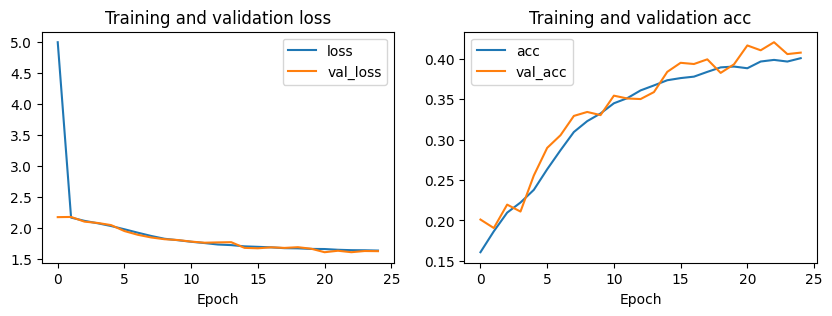

In [ ]:
#ViT visulaization for CIFAR10
plot_learning(vit_hist)

In [ ]:
# ResNet vs ViT on CIFAR-100 (did nt use this)
run_baseline("resnet", "cifar100", epochs=25)

100%|██████████| 169M/169M [00:03<00:00, 45.8MB/s]


[CIFAR100][RESNET] Epoch 001 | Train Loss 4.0591 Acc 0.0887 | Test Loss 3.5759 Acc 0.1456
[CIFAR100][RESNET] Epoch 002 | Train Loss 3.4180 Acc 0.1702 | Test Loss 3.1709 Acc 0.2191
[CIFAR100][RESNET] Epoch 003 | Train Loss 3.1245 Acc 0.2245 | Test Loss 2.9215 Acc 0.2665
[CIFAR100][RESNET] Epoch 004 | Train Loss 2.8916 Acc 0.2667 | Test Loss 2.7853 Acc 0.2930
[CIFAR100][RESNET] Epoch 005 | Train Loss 2.7154 Acc 0.3032 | Test Loss 2.6021 Acc 0.3286
[CIFAR100][RESNET] Epoch 006 | Train Loss 2.5877 Acc 0.3316 | Test Loss 2.5065 Acc 0.3496
[CIFAR100][RESNET] Epoch 007 | Train Loss 2.4895 Acc 0.3510 | Test Loss 2.4164 Acc 0.3677
[CIFAR100][RESNET] Epoch 008 | Train Loss 2.4191 Acc 0.3645 | Test Loss 2.4353 Acc 0.3728
[CIFAR100][RESNET] Epoch 009 | Train Loss 2.3506 Acc 0.3787 | Test Loss 2.4982 Acc 0.3705
[CIFAR100][RESNET] Epoch 010 | Train Loss 2.2922 Acc 0.3938 | Test Loss 2.3892 Acc 0.3875
[CIFAR100][RESNET] Epoch 011 | Train Loss 2.2451 Acc 0.4052 | Test Loss 2.3259 Acc 0.3891
[CIFAR100]

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
#Vit for CIFAR100
model, vit_hist100 = run_baseline("vit", "cifar100", epochs=25)

100%|██████████| 169M/169M [00:06<00:00, 24.7MB/s]


[CIFAR100][VIT] Epoch 001 | Train Loss 4.7640 Acc 0.0297 | Test Loss 4.3035 Acc 0.0402
[CIFAR100][VIT] Epoch 002 | Train Loss 4.1230 Acc 0.0645 | Test Loss 4.1117 Acc 0.0720
[CIFAR100][VIT] Epoch 003 | Train Loss 3.9080 Acc 0.0952 | Test Loss 3.9728 Acc 0.0896
[CIFAR100][VIT] Epoch 004 | Train Loss 3.7520 Acc 0.1185 | Test Loss 3.8097 Acc 0.1157
[CIFAR100][VIT] Epoch 005 | Train Loss 3.6568 Acc 0.1356 | Test Loss 3.6728 Acc 0.1414
[CIFAR100][VIT] Epoch 006 | Train Loss 3.5858 Acc 0.1481 | Test Loss 3.6069 Acc 0.1527
[CIFAR100][VIT] Epoch 007 | Train Loss 3.5414 Acc 0.1568 | Test Loss 3.5182 Acc 0.1642
[CIFAR100][VIT] Epoch 008 | Train Loss 3.4983 Acc 0.1640 | Test Loss 3.4840 Acc 0.1682
[CIFAR100][VIT] Epoch 009 | Train Loss 3.4649 Acc 0.1700 | Test Loss 3.4542 Acc 0.1716
[CIFAR100][VIT] Epoch 010 | Train Loss 3.4424 Acc 0.1728 | Test Loss 3.4329 Acc 0.1814
[CIFAR100][VIT] Epoch 011 | Train Loss 3.4235 Acc 0.1757 | Test Loss 3.4152 Acc 0.1834
[CIFAR100][VIT] Epoch 012 | Train Loss 3.40

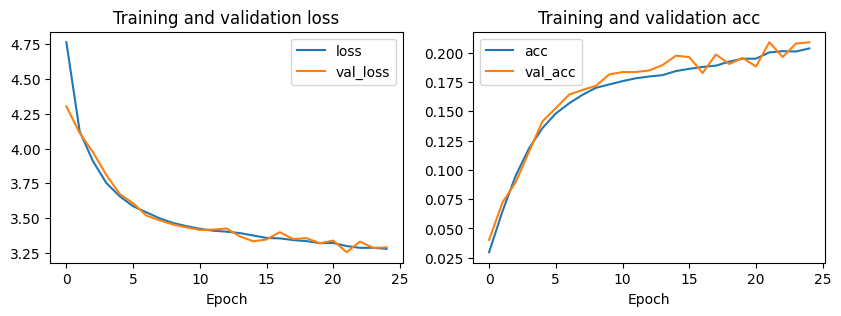

In [ ]:
#ViT CIFAR100 visual
plot_learning(vit_hist100)